# Lab 1: MLP Regression & Classification

**Name:** Christopher Hubbard & Nicholas Powell

Part 1 continues directly from what you already built — same dataset, same one-hot encoding approach, a regression MLP. Parts 2 and 3 apply that same MLP-building pattern to a new problem type: classification instead of regression. Watch closely for exactly which pieces of the code change, and which stay identical.

## Setup — Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Shared helper: plotting loss (and accuracy, when available)

We'll reuse this for all three parts so the curves are directly comparable.

In [20]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
# Part 1 — Regression with One-Hot Encoding (Ames Housing)

In [21]:
ames = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = ames.frame
df = df[["GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF", "GarageCars",
        "Neighborhood", "HouseStyle", "MSZoning", "SalePrice"]].dropna()

categorical_features = ["Neighborhood", "HouseStyle", "MSZoning"]

# One-hot encode
df_onehot = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Spilt the data into Features and Target Variables
X1 = df_onehot.drop(columns=["SalePrice"]).values.astype(float)
y1 = df_onehot["SalePrice"].values.astype(float)

# Print the shape of feature matrix
print("Feature matrix shape:", X1.shape)

Feature matrix shape: (1460, 40)


In [22]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

x1_scaler = StandardScaler()
X1_train_scaled = x1_scaler.fit_transform(X1_train)
X1_test_scaled = x1_scaler.transform(X1_test)

y1_scaler = StandardScaler()
y1_train_scaled = y1_scaler.fit_transform(y1_train.reshape(-1, 1)).flatten()
y1_test_scaled = y1_scaler.transform(y1_test.reshape(-1, 1)).flatten()

In [23]:
X1_train_scaled.shape[1]

40

**Build your MLP.** Fill in the blanks (`___`) and be ready to justify your choices.

In [67]:
model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(27, activation="relu", input_shape=(X1_train_scaled.shape[1],)),
    tf.keras.layers.Dense(27, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Q: Why does the output layer have no activation function?
# Your answer: In regression tasks, the goal is to predict a continuous numerical value, which can  be any number. An activation function like sigmoid restricts the output to a specific range (like 0-1), which is unsuitable for continuous predictions. By using no activation function, the output layer can produce any real number, allowing the model to predict the full range of the target variable.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


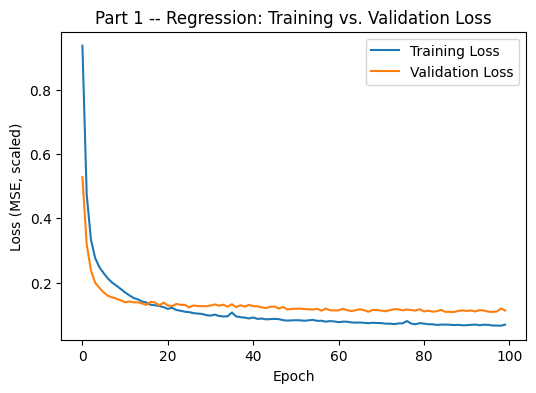

In [25]:
history_reg = model_reg.fit(
    X1_train_scaled, y1_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_reg, "Part 1 -- Regression: Training vs. Validation Loss")

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* The model has a good fit, seeing the comparison between the training and validation loss they both have high accuracy and we see that the validation score stays close and shows that the model learned well.


In [26]:
preds_scaled = model_reg.predict(X1_test_scaled).flatten()
preds_dollars = y1_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

rmse_reg = np.sqrt(np.mean((preds_dollars - y1_test) ** 2))
mae_reg = np.mean(np.abs(preds_dollars - y1_test))

print(f"Part 1 -- Test RMSE: ${rmse_reg:,.0f}")
print(f"Part 1 -- Test MAE:  ${mae_reg:,.0f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Part 1 -- Test RMSE: $30,400
Part 1 -- Test MAE:  $19,119


---
# Part 2 — Binary Classification (Pima Indians Diabetes)

Predicting whether a patient has diabetes (1) or not (0) from 8 medical measurements.

In [27]:
diabetes = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")
df2 = diabetes.frame

print(df2.shape)
print(df2["class"].value_counts())

# Q: How many classes? Is this dataset balanced or imbalanced?

# Your answer: There are 8 classes in this dataset. The dataset is a little imbalanced, with 500 testing negative and 268 testing positive.


(768, 9)
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64


In [28]:
X2 = df2.drop(columns=["class"]).values.astype(float)
y2 = (df2["class"] == "tested_positive").astype(int).values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Q: Why stratify here? Why did Part 1 not need this?
# Your answer: Part 1 did not need to stratify its data because of the nature of the problem we are identifying
# we are doing a binary classification problem and if we do not stratify the data, the model will develop a bias towards
# patients with negative tests for diabeties because its learned that it gets better results from predicting if something
# is negative than positive.

x2_scaler = StandardScaler()
X2_train_scaled = x2_scaler.fit_transform(X2_train)
X2_test_scaled = x2_scaler.transform(X2_test)

# Note: y2 is NOT scaled here.
# Q: Why not, compared to Part 1's y1_scaler?
#Your answer: For part 1's y1_scaler it is being used a regression problem where there are a wide range of variables. y1_scaler is using 'Sale Price' where the values range in the thousands and many of the values being used to predict the 'Sale Price' vary in numerical value so the model would develop bias to values of higher values if we did not scale the values. y2 does not need to be scaled because it is being used in a binary classification problem where there is no need to scale the y2 value because it is going to be 2 outputs, 1 or 0.


In [29]:
X2_train_scaled.shape[1]

8

**Build your MLP.** Fill in the blanks — this time there are two new ones: the output activation, and the loss function.

In [40]:
# Create the classification model
model_binary = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X2_train_scaled.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model_binary.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#Q: What output activation did you use, and why does it fit a yes/no prediction?

#Your answer: I used sigmoid as my output activation. The reason this fits so well is because sigmoid compresses the data into a range of 0-1, which works perfectly with a yes/no classification.

#Q: What loss function did you use, and how does it relate to what "sigmoid" outputs?

#Your answer: I used binary_crossentropy as my loss function. This works well as it relates directly to the sigmoid activation function because sigmoid outputs a probability score strictly between 0 and 1. Binary_crossentropy is the standard mathematical metric used to calculate the error between that predicted probability and the true binary target label (0 or 1).


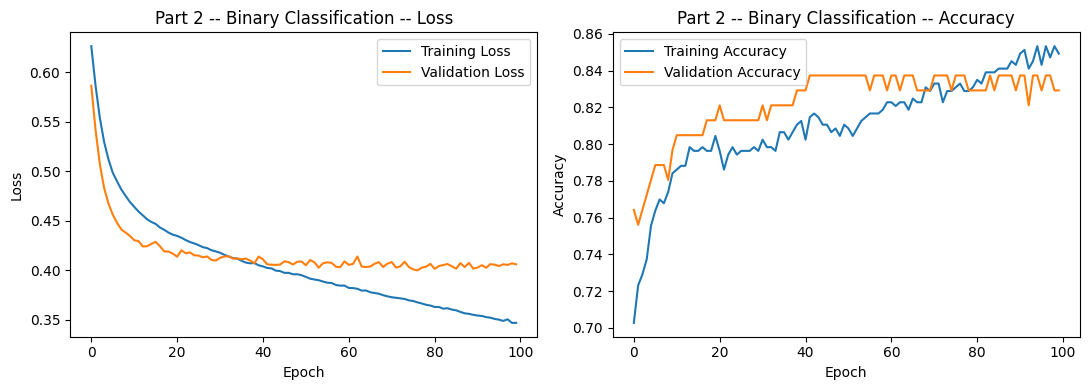

In [41]:
history_binary = model_binary.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_binary, "Part 2 -- Binary Classification", show_accuracy=True)

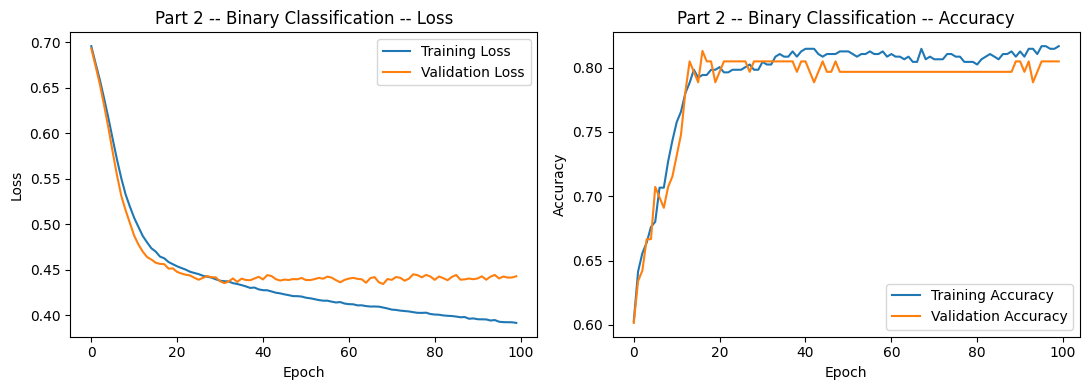

In [39]:
history_binary = model_binary.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_binary, "Part 2 -- Binary Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* The model appears to have a good fit when using a 2 layered neural network with a (32, 16) neural network. it seems it achieve a validation accuracy of around ~86%.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Part 2 -- Test Accuracy: 0.734


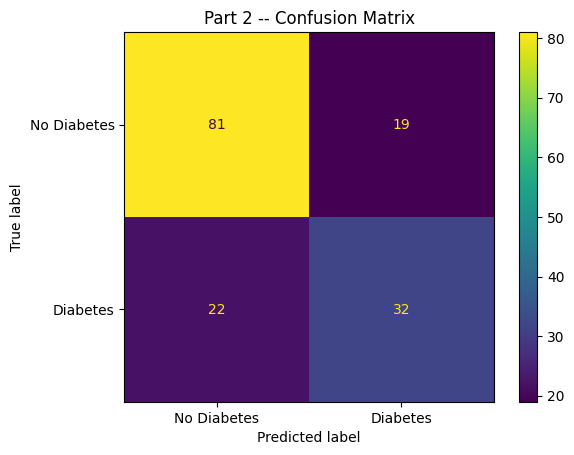

In [42]:
binary_preds = (model_binary.predict(X2_test_scaled).flatten() >= 0.5).astype(int)

acc_binary = accuracy_score(y2_test, binary_preds)
print(f"Part 2 -- Test Accuracy: {acc_binary:.3f}")

cm = confusion_matrix(y2_test, binary_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot()
plt.title("Part 2 -- Confusion Matrix")
plt.show()

# Q: In a medical diagnosis context, are false positives and false negatives
# equally costly? Which would you rather minimize, and why? How might that
# change the 0.5 threshold you'd choose?
# Your answer: In medical diagnosis, false negatives are more costly to both the doctor and the patient
# if you misdiagnoise a patient with a condition and it becomes missed it can become more medically dire.
# So we'd want to change the threshold to minimize false negatives. False positives can still be harmful to patients
# by giving them treatment they didn't need but the cost of false negatives far outweigh false positives.


---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [49]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [50]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?

# Your answer: There are 3 different classes now. The classes are reasonably balanced, with 744 "low" and 638 "medium". However, "high" is much lower at 217 total.


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [51]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [65]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(12, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation = "softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Your answers: We used 3 output neurons, this is tied to the number tied to the n_classes because of the nature of our problem
# which is deciding what type of wine belongs to what category we are trying to tie it to
# So we use 3 output neurons instead of 1 because each output neuron corresponds to one distinct class.
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Softmax activation function us used for this. Softmax takes raw scores from the output neurons and transforms the raw input ito probability distribution
# each output is between 0 and 1 and the sum of all the output values are equal to 1, which lets us interpret the output as the probabilty of an input belonging to a class (low, meidum, high wine)



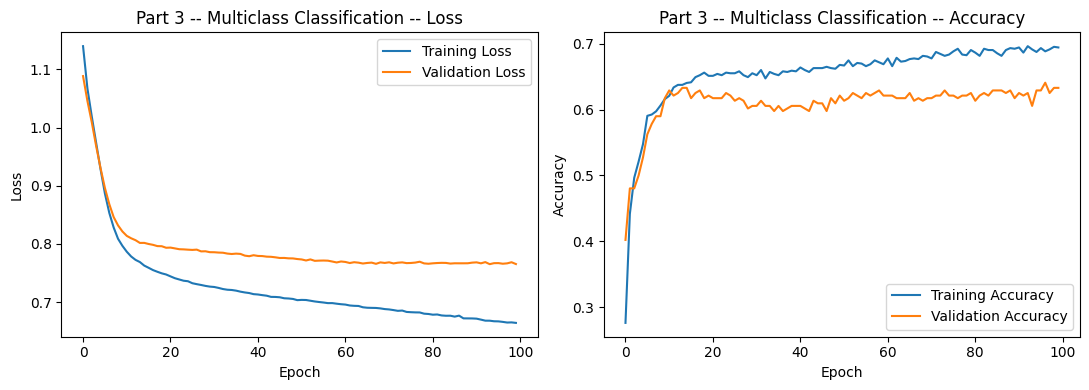

In [66]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* The model is underfitting by using a 2 layered neural net of 12 neurons in each hidden layer. There is a bit of a gap between the two and they overlap at poor performance layers.


In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Your answer: This model confuses "medium" with "low" the most often with 42 misclasses total. Yes, this makes sense given how the quality bands were constructed. This is because quality is a continuous spectrum rather than completely distinct categories, the boundary between 'Low' and 'Medium' is likely narrow and arbitrary. The data points near these cutoff thresholds will share highly similar features, making it difficult for the model to perfectly classify "low" and "medium" correctly.

---
# Comparison & Reflection

Fill in from your own three models:

| | Part 1 (Regression) | Part 2 (Binary) | Part 3 (Multiclass) |
|---|---|---|---|
| Output neurons | 1 |1 | 3|
| Output activation |None | Sigmoid | Softmax |
| Loss function | MSE | binary_crossentropy | sparse_categorical_crossentropy |
| Label format |  | No Diabetes, Diabetes| Low, Medium, High |
| Evaluation metric(s) |Accuracy | Accuracy | Accuracy |

**Write 4–5 sentences:**

1. What's the general rule connecting the *number of classes* to the *number of output neurons* and the *choice of activation*?
2. Why doesn't regression need an activation function on the output, while both classification tasks do?
3. For Part 3: why might accuracy alone be a misleading metric if your class counts are imbalanced?

*Your answer:*
1. The general rule of thumb when connecting number of classes and the number of output nerons really depends on the type of proble you are solving. If you are doing something like a multi class classification problem then you want to have the same number of output neurons to input neurons.
2. Regression models predict continuous numerical values, so an output activation function, which would squash the output into a limited range, is typically not used. Classification require model to output probabilities. So for things like binary classification we use sigmoid activation functions because it forces the output into a range of 0 or 1. And for multiclass classification problems like the wine quality part, a softmax activation functiion is used because it takes multiple outputs and converts them into a sort of probability distribution where all the classes sum up to 1. Indicating what likelihood of something belonging to a class.
3. Accuracy would be misleading if the class counts are imbalnced because the model may be just deciding everything is of the majority class to get a higher accuracy. Imbalanced classes lead to biased model output and leads to misleading results because of it.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.